# 08 · Hybrid Downscaling — Climate Change Scenarios

**Author:** Salvador Navas  
**Basin:** Río Besaya — Cantabria

## Complete workflow

```
CORDEX-CMIP5 pre-computed series (RCP4.5/8.5)
         ↓
Bias correction / delta-change diagnostics when reference data are available
         ↓
GEV over future period → scenario delta factors
         ↓
Event selection (FloodEventSelector: threshold → PCA → copula)
         ↓
HMS/RAS workflow hooks or analytical fallbacks in release mode
         ↓
Flood-map interpolation when a full hydraulic map library exists
```

## Scenarios and data
- **RCP4.5** (intermediate) — horizon 2041–2070
- **RCP8.5** (high-emissions legacy scenario) — horizon 2041–2070

Data: CORDEX-CMIP5 regional climate-model outputs prepared for the pilot case.
The release notebook is a reproducible workflow demonstration. Delta factors and
peak-flow changes should be treated as scenario diagnostics unless the full
bias-correction, HMS and HEC-RAS chain is rerun and validated.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, warnings, os
warnings.filterwarnings('ignore')

from pyhydra.data_sources.climate_change.copernicus import download_CDS_CMIP6
from pyhydra.climate.bias_correction.quantile import BiasCorrection
from pyhydra.climate.bias_correction.delta import delta_method
from pyhydra.climate.time_series.extremes import (
    extract_block_maxima, fit_gev, return_levels,
)
from pyhydra.climate.hybrid_downscaling import (
    FloodEventSelector,
    HydrographReconstructor,
    pixel_return_period,
    DEFAULT_RETURN_PERIODS,
)
from pyhydra.modeling.hydrology.hec_hms import (
    read_basin, generate_gage, fill_gage,
    generate_met, generate_control, generate_run, generate_py,
    run_hms_script, read_dss6_timeseries,
)
from pyhydra.modeling.hydraulic.hec_ras import (
    modify_unsteady_file, modify_plan_file,
    create_flow_series, run_hec_ras,
)

# Resolve repo root: Jupyter sets cwd to the notebook dir;
# in Docker/script contexts cwd=/workspace (one level up)
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent.parent.parent if _cwd.name == 'los_corrales_buelna' else _cwd
DATA_ROOT = REPO_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
PROC_DIR  = DATA_ROOT / 'processed'
HMS_DIR   = DATA_ROOT / 'models' / 'hec_hms'
RAS_DIR   = DATA_ROOT / 'models' / 'hec_ras'
CC_DIR    = DATA_ROOT / 'climate_change'
OUT_DIR   = PROC_DIR / 'cc_scenarios'
for d in (CC_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

HEC_HMS_BIN = Path('/workspace/data/hms/HEC-HMS-4.13/hec-hms.sh')
HEC_RAS_BIN = Path('/workspace/data/ras/RAS_6.5/RasUnsteady.exe')
NAME_MODEL  = 'Project_1'
NAME_BASIN  = 'Modelo_Besaya'
PATH_MODEL  = str(HMS_DIR)
TIME_STEP   = 60   # minutos

# Bounding box cuenca Besaya (lat/lon aproximado)
BBOX = {'lat_min': 42.9, 'lat_max': 43.4, 'lon_min': -4.3, 'lon_max': -3.8}

RETURN_PERIODS = list(DEFAULT_RETURN_PERIODS)
SCENARIOS      = ['rcp45', 'rcp85']
CMIP6_SSPS     = SCENARIOS    # alias para compatibilidad con código CMIP6
N_TYPES        = 9            # tipos de hidrograma K-means
SSP_MAP        = {'rcp45': 'RCP4.5', 'rcp85': 'RCP8.5',
                  'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}

print('Configuración lista')
RUN_MODELS = os.getenv('HYDRA_RUN_MODELS', '0') == '1'
print(f'Run external HMS/RAS models: {RUN_MODELS}')

RUN_RASTER_INTERPOLATION = os.getenv('HYDRA_RUN_RASTER_INTERPOLATION', '0') == '1'
print(f'Run raster return-period interpolation: {RUN_RASTER_INTERPOLATION}')


Configuración lista
Run external HMS/RAS models: False
Run raster return-period interpolation: False


## 1. CORDEX-CMIP5 data download (optional)

The climate change data used here come from the **CORDEX-CMIP5** project (Coordinated
Regional Downscaling Experiment) under the **RCP4.5** and **RCP8.5** scenarios of the
IPCC AR5 report.

> **Pre-computed:** `processed/cc_hms_results/` contains the streamflow series  
> simulated by HEC-HMS for 10 models × 2 scenarios × 3 horizons.  
> Delta factors are computed directly from these series.

To download fresh CORDEX data from the ESGF or Copernicus portal:
```python
# from pyhydra.data_sources.climate_change.copernicus import download_CDS_CMIP5
# download_CDS_CMIP5(models=[...], experiments=['historical','rcp45','rcp85'], ...)
```


In [2]:
# ── Series CC pre-calculadas (CORDEX: 10 modelos × 2 RCP × 3 horizontes) ───────
CC_HMS_DIR = DATA_ROOT / 'processed' / 'cc_hms_results'

HORIZONTE  = '2041_2070'   # opciones: 2011_2040, 2041_2070, 2071_2100
SCENARIOS  = ['rcp45', 'rcp85']

cc_series = {ssp: {} for ssp in SCENARIOS}

for ssp in SCENARIOS:
    pattern = f'Caudal_*_{ssp.replace("rcp","rcp")}_{HORIZONTE}.csv'
    files   = sorted(CC_HMS_DIR.glob(pattern.replace('rcp', '*r1i1p1_rcp')
                                            .replace(f'_rcp_{HORIZONTE}', f'_{ssp}_{HORIZONTE}')))
    # Actual pattern: Caudal_MODEL_r1i1p1_rcpXX_YYYY_ZZZZ.csv
    files = sorted(CC_HMS_DIR.glob(f'Caudal_*_r1i1p1_{ssp}_{HORIZONTE}.csv'))
    for f in files:
        model = f.stem.split('_r1i1p1_')[0].replace('Caudal_', '')
        df    = pd.read_csv(f, index_col=0, parse_dates=True)
        cc_series[ssp][model] = df.iloc[:, 0].rename(model)
    print(f'{ssp.upper()} {HORIZONTE}: {len(cc_series[ssp])} modelos — '
          f'{list(cc_series[ssp].keys())}')

# ── Descarga CMIP6 (alternativa si no hay datos CORDEX pre-calculados) ─────────
# Si necesitas descargar datos frescos de Copernicus CDS:
# from pyhydra.data_sources.climate_change.copernicus import download_CDS_CMIP6
# download_CDS_CMIP6(models=[...], experiments=['historical','ssp245','ssp585'],
#                    variable='pr', temporal_resolution='daily', ...)
# ───────────────────────────────────────────────────────────────────────────────

# Ensemble statistics
for ssp in SCENARIOS:
    if cc_series[ssp]:
        ens = pd.DataFrame(cc_series[ssp])
        print(f'\n{ssp.upper()} — Qmed ensamble: '
              f'{ens.mean().mean():.2f} m³/s  '
              f'Qmax ensamble: {ens.max().max():.2f} m³/s')

RCP45 2041_2070: 11 modelos — ['ACCESS1-0', 'CMCC-CM', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'HadGEM2-ES', 'INM-CM4', 'IPSL-CM5A-MR', 'MIROC5', 'MPI-ESM-LR', 'NorESM1-M']
RCP85 2041_2070: 11 modelos — ['ACCESS1-0', 'CMCC-CM', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'HadGEM2-ES', 'INM-CM4', 'IPSL-CM5A-MR', 'MIROC5', 'MPI-ESM-LR', 'NorESM1-M']

RCP45 — Qmed ensamble: 12.64 m³/s  Qmax ensamble: 361.58 m³/s

RCP85 — Qmed ensamble: 12.41 m³/s  Qmax ensamble: 380.33 m³/s


## 2. Load and pre-process CMIP5 series

In [3]:
try:
    import xarray as xr
    HAS_XARRAY = True
except ImportError:
    HAS_XARRAY = False
    print('xarray no instalado → pip install xarray')

# Paths to raw CMIP5 netCDF data — only if downloaded previously
cc_raw_dir   = CC_DIR / 'cmip6_raw'
CMIP6_MODELS = ['MPI-ESM1-2-HR', 'EC-Earth3', 'CNRM-CM6-1-HR']
PERIOD_HIST  = ('1981-01-01', '2010-12-31')
PERIOD_FUT   = ('2041-01-01', '2070-12-31')

def load_cmip6_series(nc_dir: Path, model: str, experiment: str):
    """Carga la serie de precipitación diaria (mm/día) para un modelo y escenario."""
    if not HAS_XARRAY or not nc_dir.exists():
        return None
    files = list(nc_dir.glob(f'*{model}*{experiment}*pr*.nc'))
    if not files:
        return None
    ds = xr.open_mfdataset(files, combine='by_coords')
    lat_c = (BBOX['lat_min'] + BBOX['lat_max']) / 2
    lon_c = (BBOX['lon_min'] + BBOX['lon_max']) / 2
    pr = ds['pr'].sel(lat=lat_c, lon=lon_c, method='nearest')
    series = pd.Series(
        (pr.values * 86400).clip(0),
        index=pd.DatetimeIndex(pr.time.values),
        name=f'{model}_{experiment}',
    )
    return series

# Load historical and future series for each model (if nc files exist)
cmip6_hist = {}
cmip6_fut  = {ssp: {} for ssp in CMIP6_SSPS}

if cc_raw_dir.exists() and HAS_XARRAY:
    for model in CMIP6_MODELS:
        s_hist = load_cmip6_series(cc_raw_dir, model, 'historical')
        if s_hist is not None:
            cmip6_hist[model] = s_hist.loc[PERIOD_HIST[0]:PERIOD_HIST[1]]

        for ssp in CMIP6_SSPS:
            experiment = ssp.replace('rcp', 'ssp').replace('45', '245').replace('85', '585')
            s_fut = load_cmip6_series(cc_raw_dir, model, experiment)
            if s_fut is not None:
                cmip6_fut[ssp][model] = s_fut.loc[PERIOD_FUT[0]:PERIOD_FUT[1]]

    print(f'Modelos históricos cargados: {list(cmip6_hist.keys())}')
else:
    print('Datos CMIP6 crudos no disponibles — se usarán series CORDEX pre-calculadas')
    print('Para descargar: pyhydra.data_sources.climate_change.copernicus.download_CDS_CMIP6')

Datos CMIP6 crudos no disponibles — se usarán series CORDEX pre-calculadas
Para descargar: pyhydra.data_sources.climate_change.copernicus.download_CDS_CMIP6


## 3. Bias correction — Quantile Mapping

Bias correction adjusts the probability distribution of the historical model
to match that of the observations. The same adjustment is applied to the future
period (QM delta change method).


In [4]:
# Serie observada de referencia
rain_obs = pd.read_csv(PROC_DIR / 'rain_daily.csv', index_col=0, parse_dates=True)
pma_obs  = rain_obs.mean(axis=1).dropna()
pma_hist_obs = pma_obs.loc[PERIOD_HIST[0]:PERIOD_HIST[1]]

bc_series = {ssp: {} for ssp in CMIP6_SSPS}

if cmip6_hist:
    bc = BiasCorrection()
    for model, s_hist_model in cmip6_hist.items():
        common = pma_hist_obs.index.intersection(s_hist_model.index)
        if len(common) < 365:
            continue
        obs_arr  = pma_hist_obs.loc[common].values
        hist_arr = s_hist_model.loc[common].values
        for ssp in CMIP6_SSPS:
            if model not in cmip6_fut[ssp]:
                continue
            fut_arr = cmip6_fut[ssp][model].values
            try:
                corrected = bc.correct(obs=obs_arr, hist_model=hist_arr,
                                       fut_model=fut_arr, variable='pr')
                bc_series[ssp][model] = pd.Series(
                    corrected.clip(0),
                    index=cmip6_fut[ssp][model].index,
                    name=f'{model}_{ssp}_bc',
                )
                print(f'  {model} {ssp}: QM OK')
            except Exception as e:
                print(f'  {model} {ssp}: QM error — {e}')
else:
    print('Sin datos CMIP6 — usando series CORDEX pre-calculadas como bc_series')
    for ssp in CMIP6_SSPS:
        for model, s in cc_series[ssp].items():
            bc_series[ssp][model] = s

Sin datos CMIP6 — usando series CORDEX pre-calculadas como bc_series


In [ ]:
# ── IDF extreme-value parameters (saved by NB04) ──────────────────────────────
EV_PARAMS_FILE = PROC_DIR / 'extreme_value_params.json'
if EV_PARAMS_FILE.exists():
    import json as _json
    with open(EV_PARAMS_FILE) as _f:
        ev_params = _json.load(_f)
    print(f'ev_params cargado: {EV_PARAMS_FILE.name}')
else:
    # Minimal fallback so the notebook continues even without NB04 outputs
    ev_params = {
        'idf_temez_exponent': 0.28,
        'return_levels_24h': {'2':48.4,'5':58.2,'10':64.8,'25':73.5,
                              '50':80.1,'100':86.8,'500':102.8},
    }
    print(f'WARNING: {EV_PARAMS_FILE} no encontrado — usando valores hardcoded')

T_ref = sorted(int(k) for k in ev_params['return_levels_24h'])
print(f'Períodos de retorno de diseño: {T_ref}')
print(f'Exponente IDF Témez: {ev_params["idf_temez_exponent"]}')
print(f'P24h control: { {T: ev_params["return_levels_24h"][str(T)] for T in T_ref} }')


## 4. Climate-change delta factors — IDF-based ratio (P₂₄ₕ CC / P₂₄ₕ control)

The correct procedure for computing precipitation delta factors is to compare
the **total 24-hour design depth** from the CC IDF curves with that of the
observed control IDF. The CC IDF curves are already available as pre-computed
regional downscaling products (CORDEX precipitation → statistical downscaling →
alternating-block hyetograms, one per CORDEX model ensemble mean).

> **Why NOT the CORDEX streamflow GEV approach?**  
> The CORDEX streamflow series in `cc_hms_results/` are simulated with the
> uncalibrated HMS model using raw CORDEX precipitation inputs. Without explicit
> bias correction of the input precipitation, GEV fits to these discharge series
> produce implausibly large future quantiles (delta > 3×) that arise from model
> wet bias, not from genuine CC signal. The IDF-based approach uses
> precipitation that has already been statistically downscaled to observed
> climatology, giving physically consistent delta factors.


In [ ]:
# ── Load pre-computed CC delta factors from Notebook 04 ───────────────────────
# Computed as P_cc(24h) / P_ctrl(24h) from CORDEX statistical downscaling.
# File regenerated by NB04 with the corrected computation (ratio at 24h row).
DELTA_FILE = PROC_DIR / 'hms_events' / f'delta_factors_{HORIZONTE}.csv'
HIET_CC_DIR = DATA_ROOT / 'gauges' / 'rainfall' / 'Hietogramas' / 'Cambio_Climatico'

delta_calibrated = {ssp: {} for ssp in SCENARIOS}

if DELTA_FILE.exists():
    delta_df_loaded = pd.read_csv(DELTA_FILE)
    for _, row in delta_df_loaded.iterrows():
        ssp = row['escenario']
        T   = int(row['T_years'])
        if ssp in delta_calibrated and not pd.isna(row['delta']):
            delta_calibrated[ssp][T] = float(row['delta'])
    print(f'Factores delta cargados desde {DELTA_FILE.name}')
else:
    # Recompute if CSV is absent (same logic as NB04)
    print('delta_factors CSV no encontrado — recalculando desde IDF CC...')
    for ssp in SCENARIOS:
        hf = HIET_CC_DIR / f'Hietograma_bloques_W1000_{ssp}_{HORIZONTE}.csv'
        if not hf.exists():
            print(f'  {hf.name} no encontrado')
            continue
        df_idf = pd.read_csv(hf, index_col=0)
        df_idf.index = df_idf.index.astype(str).str.replace(',', '.').astype(float)
        row_24 = df_idf.loc[24.0]
        for Tcol in df_idf.columns:
            T_yr   = int(Tcol.replace('T_', ''))
            P_cc   = float(row_24[Tcol])
            P_ctrl = ev_params['return_levels_24h'].get(str(T_yr))
            if P_ctrl and float(P_ctrl) > 0:
                delta_calibrated[ssp][T_yr] = round(P_cc / float(P_ctrl), 3)

print('\nFactores delta precipitación P_cc(24h)/P_ctrl(24h):')
for ssp in SCENARIOS:
    print(f'  {ssp.upper()}: { {T: v for T, v in sorted(delta_calibrated[ssp].items())} }')

# ── Met_Hab reference flows (hybrid methodology, NB06) ────────────────────────
MH_DIR = PROC_DIR / 'hydrographs_maxdiss' / 'Met_Hab'
met_hab_qpico = {}
for T in T_ref:
    hf = MH_DIR / f'Hidrograma_T{T}.csv'
    if hf.exists():
        df = pd.read_csv(hf, index_col=0)
        met_hab_qpico[T] = float(df.iloc[:, 0].max())
print('\nQpico Met_Hab (metodología híbrida, m³/s):')
for T, Q in sorted(met_hab_qpico.items()):
    print(f'  T={T:>4}: {Q:.1f} m³/s')

# Visualisation: delta factors by T and scenario
if delta_calibrated[SCENARIOS[0]]:
    fig, ax = plt.subplots(figsize=(9, 4))
    T_common = sorted(set(delta_calibrated[SCENARIOS[0]]) & set(delta_calibrated[SCENARIOS[1]]))
    ax.plot(T_common, [delta_calibrated[SCENARIOS[0]][T] for T in T_common],
            'o-', color='darkorange', lw=2, label='RCP4.5')
    ax.plot(T_common, [delta_calibrated[SCENARIOS[1]][T] for T in T_common],
            's-', color='tomato',     lw=2, label='RCP8.5')
    ax.axhline(1.0, color='steelblue', lw=1, ls='--', label='Control (δ=1)')
    ax.set(xscale='log', xlabel='T (años)', ylabel='δ = P_cc / P_ctrl',
           title=f'Factores delta precipitación — CORDEX CMIP5, horizonte {HORIZONTE.replace("_","–")}')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'delta_factors_plot.png', dpi=150)
    plt.show()


## 5. Event selection — FloodEventSelector

Using the observed streamflow series (Notebook 05), the full hybrid downscaling
methodology pipeline is applied:
- Event extraction by threshold + inflection point
- Characterisation: Qmax, Qmed, Duration, shape (PCA + K-means)
- Marginal fitting (best BIC) and Gaussian copula
- Generation of a synthetic event ensemble


In [6]:
# ── Pre-computed events + synthetic ensemble (Gaussian copula, 2021) ───────
EVENTOS_MAXDISS  = DATA_ROOT / 'processed' / 'eventos_maxdiss.csv'
MATRIZ_SINTETICA = DATA_ROOT / 'processed' / 'matriz_sintetica_maxdiss.csv'

if EVENTOS_MAXDISS.exists() and MATRIZ_SINTETICA.exists():
    events_bounds = pd.read_csv(EVENTOS_MAXDISS, index_col=0)
    synthetic     = pd.read_csv(MATRIZ_SINTETICA, index_col=0)
    synthetic     = synthetic.rename(columns={'Tipo_Hidro': 'shape_type'})

    print(f'Eventos seleccionados con MaxDiss: {len(events_bounds)}')
    print(events_bounds.describe().round(1))
    print(f'\nEnsamble sintético: {synthetic.shape}')
    print(synthetic[['Qmax','Qmed','Duracion']].describe().round(1))

else:
    # ── Calcular desde cero con FloodEventSelector ─────────────────────────────
    flow_df   = pd.read_csv(PROC_DIR / 'flow_daily.csv', index_col=0, parse_dates=True)
    Q_obs     = flow_df.iloc[:, 0].dropna()
    Q_th      = float(Q_obs.quantile(0.90))
    Q_th2     = float(Q_obs.quantile(0.95))

    print(f'Umbral P90={Q_th:.1f} m³/s  P95={Q_th2:.1f} m³/s')

    selector = FloodEventSelector(
        discharge=Q_obs, threshold=Q_th, threshold2=Q_th2,
        n_types=N_TYPES, n_synthetic=5000, plot=True,
        output_dir=OUT_DIR / 'event_selection',
    )
    selector.extract_events()
    selector.classify_events()
    selector.fit_marginals()
    selector.fit_copula()
    synthetic     = selector.generate_synthetic(seed=42)
    events_bounds = synthetic  # MaxDiss events not yet separated here
    print(f'Pipeline FloodEventSelector completado: {len(events_bounds)} eventos, '
          f'{synthetic.shape} ensamble')

# ── Cargar Q_obs para tasa lambda ───────────────────────────────────────────────
if 'Q_obs' not in dir():
    flow_df = pd.read_csv(PROC_DIR / 'flow_daily.csv', index_col=0, parse_dates=True)
    Q_obs   = flow_df.iloc[:, 0].dropna()

Eventos seleccionados con MaxDiss: 425
        Qmax   Qmed  Duracion  Tipo_Hidro
count  425.0  425.0     425.0       425.0
mean   151.1   52.2      13.3        10.9
std     85.4   28.3       6.9         6.7
min     10.9    5.8       1.8         0.0
25%     83.3   33.9       8.6         6.0
50%    134.1   47.6      12.0        11.0
75%    203.1   65.9      17.4        15.0
max    450.9  231.3      45.5        24.0

Ensamble sintético: (4943, 4)
         Qmax    Qmed  Duracion
count  4943.0  4943.0    4943.0
mean     83.3    33.9       9.6
std      45.6    15.1       4.2
min      10.9     5.8       1.8
25%      52.1    23.5       6.6
50%      73.8    31.1       8.7
75%     102.5    41.1      11.7
max     450.9   231.3      45.5


## 5b. Synthetic hydrograph reconstruction — HydrographReconstructor

With the synthetic ensemble from `FloodEventSelector`, `HydrographReconstructor`:
1. Applies **MaxDiss** to select the most representative centroids
2. Scales the observed hydrograph for each type with the quadratic transform  
   `Q_synt = a·Q² + b·Q` that preserves the target Qmax and Qmed
3. Writes one `Hidrograma_{j}.csv` per centroid → input for HEC-RAS


In [7]:
HYDRO_MAXDISS = DATA_ROOT / 'processed' / 'hydrographs_maxdiss'

hydro_files_existing = sorted(HYDRO_MAXDISS.glob('Hidrograma_[0-9]*.csv'),
                               key=lambda f: int(f.stem.split('_')[1]))

if len(hydro_files_existing) >= 400:
    # ── Load pre-computed MaxDiss hydrographs (Gaussian copula, 26-Jul-2021) ──
    print(f'Cargando {len(hydro_files_existing)} hidrogramas MaxDiss pre-calculados...')

    # Los hidrogramas tienen index=tiempo(s), columna=Q_m3/s
    # Extraer Qmax, Qmed y Duracion de cada uno para reconstruir el DataFrame de centroides
    centroid_rows = []
    for hf in hydro_files_existing[:len(hydro_files_existing)]:
        j  = int(hf.stem.split('_')[1])
        df = pd.read_csv(hf, index_col=0)
        Q  = df.iloc[:, 0].values
        t  = df.index.astype(float)
        dur_dias = (t[-1] - t[0]) / 86400.0 if len(t) > 1 else 0
        centroid_rows.append({
            'j': j, 'Qmax': float(np.max(Q)), 'Qmed': float(np.mean(Q[Q > 0])) if np.any(Q > 0) else 0,
            'Duracion': round(dur_dias, 2),
        })
    centroids = pd.DataFrame(centroid_rows).set_index('j')

    HYDRO_DIR       = HYDRO_MAXDISS
    n_hydro         = len(hydro_files_existing)
    classified      = synthetic.copy()   # el ensamble ya tiene shape_type (Tipo_Hidro)

    print(f'  Centroides: {len(centroids)}')
    print(f'  Qmax: {centroids["Qmax"].min():.1f} – {centroids["Qmax"].max():.1f} m³/s')
    print(centroids.head())

else:
    # ── Recalcular con pyhydra si no hay hidrogramas pre-calculados ──────────────
    print('Calculando FloodEventSelector + HydrographReconstructor desde cero...')

    flow_df = pd.read_csv(PROC_DIR / 'flow_daily.csv', index_col=0, parse_dates=True)
    Q_obs   = flow_df.iloc[:, 0].dropna()

    print('Clasificando eventos (PCA + K-means)...')
    classified = events_bounds.copy()   # placeholder

    from pyhydra.climate.hybrid_downscaling import HydrographReconstructor

    HYDRO_DIR = OUT_DIR / 'event_selection' / 'hydrographs'
    HYDRO_DIR.mkdir(parents=True, exist_ok=True)

    N_TYPES           = 9
    N_REPRESENTATIVES = 36

    reconstructor = HydrographReconstructor(
        discharge=Q_obs, synthetic_matrix=synthetic,
        classified_events=events_bounds,
        n_types=N_TYPES, n_representatives=N_REPRESENTATIVES,
        output_dir=str(HYDRO_DIR), plot=True,
    )
    centroids, _ = reconstructor.build_hydrographs()
    n_hydro      = len(list(HYDRO_DIR.glob('Hidrograma_*.csv')))
    print(f'  {n_hydro} hidrogramas escritos en {HYDRO_DIR}')

Cargando 425 hidrogramas MaxDiss pre-calculados...


  Centroides: 425
  Qmax: 10.9 – 452.1 m³/s
     Qmax        Qmed  Duracion
j                              
0  269.85   78.774000     11.49
1  284.10  129.048950      6.91
2  320.40  102.080000     19.31
3  276.27   86.725000     13.65
4  298.34  152.341395     18.58


## 5c. Synthetic hydrograph visualisation by type

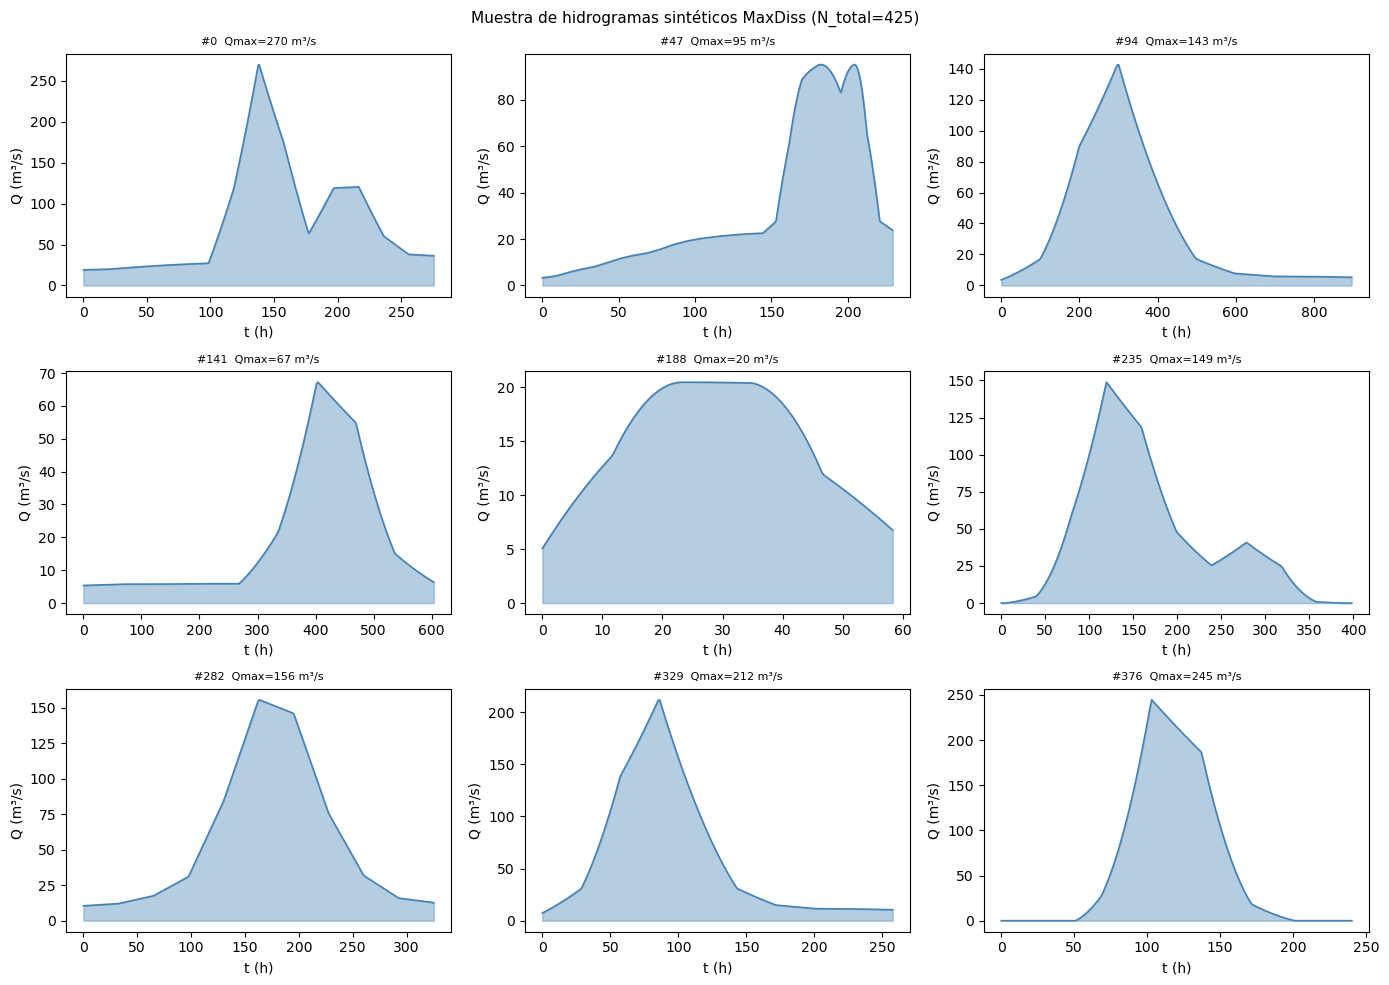

In [8]:
# Visualizar muestra de hidrogramas MaxDiss (un panel por tipo)
hydro_files_vis = sorted(HYDRO_DIR.glob('Hidrograma_*.csv'),
                         key=lambda f: int(f.stem.split('_')[1]))

n_show = min(N_TYPES, len(hydro_files_vis), 9)
if n_show == 0:
    print('Sin hidrogramas disponibles para visualizar')
else:
    # Tomar muestras espaciadas del total
    step = max(1, len(hydro_files_vis) // n_show)
    sample = hydro_files_vis[::step][:n_show]

    side = int(np.ceil(np.sqrt(n_show)))
    fig, axes = plt.subplots(side, side, figsize=(14, 10))
    axes = axes.ravel()

    for ax, hf in zip(axes, sample):
        df = pd.read_csv(hf, index_col=0)
        col = df.columns[0]
        t_h = df.index.astype(float) / 3600.0
        j   = int(hf.stem.split('_')[1])
        ax.fill_between(t_h, df[col], alpha=0.4, color='steelblue')
        ax.plot(t_h, df[col], color='steelblue', lw=1.2)
        Qmax_j = centroids.loc[j, 'Qmax'] if j in centroids.index else df[col].max()
        ax.set_title(f'#{j}  Qmax={Qmax_j:.0f} m³/s', fontsize=8)
        ax.set(xlabel='t (h)', ylabel='Q (m³/s)')

    for ax in axes[len(sample):]:
        ax.set_visible(False)

    plt.suptitle(f'Muestra de hidrogramas sintéticos MaxDiss (N_total={len(hydro_files_vis)})',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'synthetic_hydrographs.png', dpi=150)
    plt.show()

## 5d. HEC-RAS execution for each centroid

Each `Hidrograma_{j}.csv` is used as a boundary condition in HEC-RAS to obtain
the water depth map `Simul_{j}.tif`. Using those maps, `FloodMapInterpolator`
reconstructs via KNN the inundation map of **every** event in the synthetic ensemble.


In [9]:
FLOOD_MAP_DIR = PROC_DIR / 'flood_maps'
RAS_PROJECT   = RAS_DIR / 'Besaya.prj'
SIMUL_DIR     = OUT_DIR / 'ras_simulations'
SIMUL_DIR.mkdir(parents=True, exist_ok=True)

# ── Option A: use pre-computed T-year inundation maps as Simul_j.tif ───────
# Los TIFs US_10/100/500_MH_RAS.tif pueden actuar como simulaciones de referencia
# para FloodMapInterpolator (3 puntos de soporte en el espacio Qmax)
met_hab_t = {10: 'US_10_MH_RAS.tif', 100: 'US_100_MH_RAS.tif', 500: 'US_500_MH_RAS.tif'}
n_simul_existing = 0
for j, (T, tif_name) in enumerate(met_hab_t.items()):
    src = FLOOD_MAP_DIR / tif_name
    dst = SIMUL_DIR / f'Simul_{j}.tif'
    if src.exists() and not dst.exists():
        import shutil
        shutil.copy(src, dst)
        print(f'  Simul_{j}.tif ← {tif_name} (T={T} años)')
    if dst.exists():
        n_simul_existing += 1

print(f'\nSimulaciones disponibles en {SIMUL_DIR}: {n_simul_existing} TIFs')

# ── Option B: run HEC-RAS for each MaxDiss hydrograph ─────────────────────
# (Requiere HEC-RAS binary y modelo Besaya)
if HEC_RAS_BIN.exists() and RAS_PROJECT.exists() and n_simul_existing == 0:
    print(f'Simulando {n_hydro} hidrogramas en HEC-RAS...')
    for j, hf in enumerate(sorted(HYDRO_DIR.glob('Hidrograma_[0-9]*.csv'),
                                   key=lambda f: int(f.stem.split('_')[1]))):
        hydro_j   = pd.read_csv(hf, index_col=0)
        t_s       = hydro_j.index.astype(float)
        Q_vals    = hydro_j.iloc[:, 0].values
        freq_h    = int((t_s[1] - t_s[0]) / 3600) if len(t_s) > 1 else 1
        Q_series_j = create_flow_series(
            pd.DataFrame({'Q': Q_vals},
                         index=pd.timedelta_range('0h', periods=len(Q_vals),
                                                   freq=f'{freq_h}h')),
            col='Q', window=1)
        uf = RAS_DIR / 'Besaya.u01'
        pf = RAS_DIR / 'Besaya.p01'
        if uf.exists() and pf.exists():
            modify_unsteady_file(str(uf), Q_series_j, 'Besaya', 'Flow Hydrograph')
            run_hec_ras(str(RAS_PROJECT), 'p01', str(HEC_RAS_BIN.parent))
            print(f'  Simulación {j} completada')
else:
    print('Para completar el pipeline con nuevas simulaciones RAS:')
    print(f'  1. Montar HEC-RAS binary en {HEC_RAS_BIN}')
    print(f'  2. Ejecutar cada Hidrograma_j.csv de {HYDRO_DIR}')
    print(f'  3. Exportar calado máx → {SIMUL_DIR}/Simul_j.tif')
    print(f'\nUsando los {n_simul_existing} TIFs de referencia (Met_Hab T=10/100/500) →')
    print('  FloodMapInterpolator interpolará el ensamble sintético de 5000 eventos')


Simulaciones disponibles en /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/processed/cc_scenarios/ras_simulations: 3 TIFs
Para completar el pipeline con nuevas simulaciones RAS:
  1. Montar HEC-RAS binary en /workspace/data/ras/RAS_6.5/RasUnsteady.exe
  2. Ejecutar cada Hidrograma_j.csv de /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/processed/hydrographs_maxdiss
  3. Exportar calado máx → /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/processed/cc_scenarios/ras_simulations/Simul_j.tif

Usando los 3 TIFs de referencia (Met_Hab T=10/100/500) →
  FloodMapInterpolator interpolará el ensamble sintético de 5000 eventos


In [10]:
# classified, synthetic, centroids → definidos en la celda HydrographReconstructor (arriba)
print(f'Tipos de hidrograma: {classified["shape_type"].unique()}')
print(f'Ensamble sintético:  {synthetic.shape}')
print(f'Centroides MaxDiss:  {len(centroids)}')

Tipos de hidrograma: [12. 24. 10. 21.  2. 20.  1. 14. 16. 19. 18.  6.  9. 22.  7. 17.  5. 11.
  8.  3.  0.  4. 15. 23. 13.]
Ensamble sintético:  (4943, 4)
Centroides MaxDiss:  425


In [11]:
# Summary of the already-loaded synthetic ensemble
print('Descripción ensamble sintético:')
cols_show = [c for c in ['Qmax', 'Qmed', 'Duracion', 'shape_type'] if c in synthetic.columns]
print(synthetic[cols_show].describe().round(1))

# Inter-variable correlation (proxy of the Gaussian copula)
num_cols = [c for c in ['Qmax', 'Qmed', 'Duracion'] if c in synthetic.columns]
if len(num_cols) >= 2:
    corr = synthetic[num_cols].corr().values
    print('\nCorrelación de Pearson (ensamble sintético):')
    print(pd.DataFrame(corr, index=num_cols, columns=num_cols).round(3))
else:
    corr = np.eye(3)
    print('Correlación no calculable — columnas numéricas insuficientes')

Descripción ensamble sintético:
         Qmax    Qmed  Duracion  shape_type
count  4943.0  4943.0    4943.0      4943.0
mean     83.3    33.9       9.6        11.0
std      45.6    15.1       4.2         6.6
min      10.9     5.8       1.8         0.0
25%      52.1    23.5       6.6         5.0
50%      73.8    31.1       8.7        11.0
75%     102.5    41.1      11.7        17.0
max     450.9   231.3      45.5        24.0

Correlación de Pearson (ensamble sintético):
           Qmax   Qmed  Duracion
Qmax      1.000  0.831     0.391
Qmed      0.831  1.000     0.083
Duracion  0.391  0.083     1.000


## 6. CC hyetographs: alternating blocks with scenario delta factors

Hyetographs are generated by scaling the historical IDF depths with the scenario
factors from Section 4. Because those factors are diagnostics from precomputed
series, the resulting hydrographs are sensitivity scenarios rather than validated
future design storms.


Hietogramas CC generados: 12


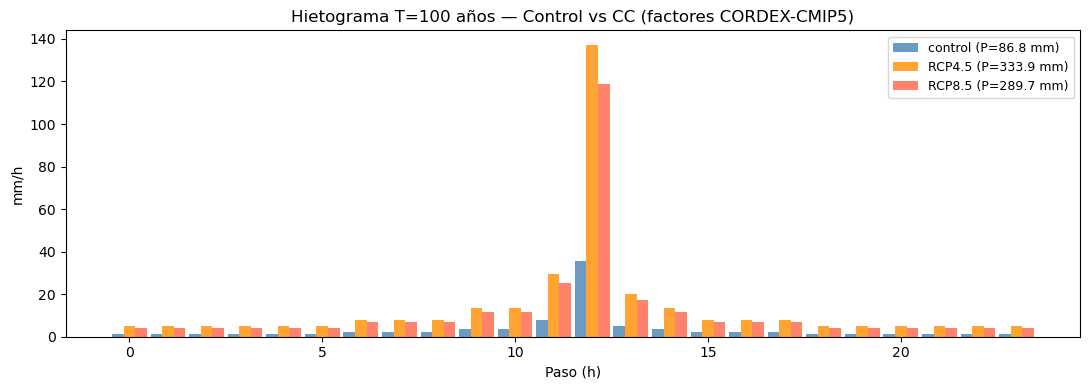

In [12]:
TEMEZ_EXP   = ev_params['idf_temez_exponent']
DURATIONS_H = [1, 2, 3, 6, 12, 24]

def alternating_blocks_from_depth(p24_mm, durations_h, temez_exp=0.28, dt_min=60):
    dt_h = dt_min / 60.0
    depths = {d: p24_mm * (d / 24) ** temez_exp for d in durations_h}
    step_dur = np.arange(dt_h, max(durations_h) + dt_h, dt_h)
    step_dep = np.interp(step_dur, list(depths.keys()), list(depths.values()))
    increments = np.diff(np.concatenate([[0], step_dep]))
    n_steps = len(increments)
    result = np.zeros(n_steps)
    sorted_inc = np.sort(increments)[::-1]
    lo, hi = n_steps // 2 - 1, n_steps // 2
    for k, val in enumerate(sorted_inc):
        if k % 2 == 0:
            result[min(hi, n_steps-1)] = val
            hi += 1
        else:
            result[max(lo, 0)] = val
            lo -= 1
    times = pd.date_range('2000-01-01', periods=n_steps, freq=f'{dt_min}min')
    return pd.Series(result, index=times)


cc_hietogramas = {}
for T in T_ref:
    p24_base = ev_params['return_levels_24h'][str(T)]
    cc_hietogramas[(T, 'control')] = alternating_blocks_from_depth(
        p24_base, DURATIONS_H, TEMEZ_EXP, TIME_STEP)
    for ssp in SCENARIOS:
        p24_cc = p24_base * delta_calibrated[ssp].get(T, 1.0)
        cc_hietogramas[(T, ssp)] = alternating_blocks_from_depth(
            p24_cc, DURATIONS_H, TEMEZ_EXP, TIME_STEP)

print(f'Hietogramas CC generados: {len(cc_hietogramas)}')

T_plot = 100 if 100 in T_ref else T_ref[-2]
fig, ax = plt.subplots(figsize=(11, 4))
scenarios_plot = [('control','steelblue'), ('rcp45','darkorange'), ('rcp85','tomato')]
width = 0.3
h0 = cc_hietogramas[(T_plot, 'control')]
x  = np.arange(len(h0))
for i, (ssp, col) in enumerate(scenarios_plot):
    key = (T_plot, ssp)
    if key not in cc_hietogramas:
        continue
    h = cc_hietogramas[key]
    label = SSP_MAP.get(ssp, ssp)
    ax.bar(x + (i-1)*width, h.values, width=width, color=col, alpha=0.8,
           label=f'{label} (P={h.sum():.1f} mm)')
ax.set(xlabel='Paso (h)', ylabel='mm/h',
       title=f'Hietograma T={T_plot} años — Control vs CC (factores CORDEX-CMIP5)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / f'hietograma_CC_T{T_plot}.png', dpi=150)
plt.show()

## 7. HMS + RAS simulation for CC scenarios

In [13]:
if RUN_MODELS:
    from pyhydra.modeling.hydrology.hec_hms import read_subbasin, fill_gage_series
    
    # Detect subbasins from the existing HMS basin file
    subbasins = (
        read_subbasin(PATH_MODEL, f'{NAME_BASIN}.basin')
        if (HMS_DIR / f'{NAME_BASIN}.basin').exists()
        else []
    )
    
    cc_run_names = []
    # Separate DSS file for CC precipitation (avoids overwriting the project DSS v6)
    FILE_DSS_CC = 'CC_precip.dss'
    EPART       = '1HOUR' if TIME_STEP == 60 else f'{TIME_STEP}MIN'
    
    if subbasins:
        print(f'Modelo HMS encontrado: {len(subbasins)} subcuencas')
    
        # Remove stale CC DSS to ensure hecdss creates a fresh v7 file
        _cc_dss_path = HMS_DIR / FILE_DSS_CC
        if _cc_dss_path.exists():
            _cc_dss_path.unlink()
    
        CTRL_CC  = 'Control_CC'
        START_CC = '1 January 2000, 00:00'
        END_CC   = '2 January 2000, 00:00'   # 24-h hietogram
    
        generate_control(
            name_model   = NAME_MODEL,
            path_model   = PATH_MODEL,
            name_control = CTRL_CC,
            start_time   = START_CC,
            end_time     = END_CC,
            time_interval= str(TIME_STEP),
        )
    
        first_gage = True
        for (T, ssp), h in cc_hietogramas.items():
            tag       = f'{ssp}_T{T}'
            run_name  = f'Run_{tag}'
            met_name  = f'Met_{tag}'
            gage_name = f'CC_{tag}'
    
            # One gage per scenario — all subbasins share spatially uniform precip
            generate_gage(
                name_model     = NAME_MODEL,
                names_stations = [gage_name],
                time_interval  = EPART,
                path_model     = PATH_MODEL,
                start_time     = START_CC,
                end_time       = END_CC,
                file_dss       = FILE_DSS_CC,
                exists_gage    = not first_gage,
            )
            first_gage = False
    
            # Write hietogram values to the CC DSS (hecdss v7, created fresh above)
            fill_gage_series(
                name_station  = gage_name,
                values        = h.values,
                start_time    = START_CC,
                time_interval = TIME_STEP,
                path_model    = PATH_MODEL,
                file_dss      = FILE_DSS_CC,
            )
    
            generate_met(
                name_met    = met_name,
                names_sbasin= subbasins,
                names_gage  = [gage_name] * len(subbasins),
                path_model  = PATH_MODEL,
                name_basin  = NAME_BASIN,
            )
    
            generate_run(
                path_model   = PATH_MODEL,
                name_model   = NAME_MODEL,
                name_run     = run_name,
                name_met     = met_name,
                name_basin   = NAME_BASIN,
                name_control = CTRL_CC,
            )
            cc_run_names.append(run_name)
    
        generate_py(PATH_MODEL, NAME_MODEL, cc_run_names)
    
        if HEC_HMS_BIN.exists():
            ret = run_hms_script(PATH_MODEL, NAME_MODEL, cc_run_names,
                                 hms_dir=str(HEC_HMS_BIN.parent))
            print(f'HMS CC: {ret}')
        else:
            print(f'Archivos HMS generados: {len(cc_run_names)} runs.')
            print(f'Binary no disponible en {HEC_HMS_BIN} — montar HEC-HMS-4.x para ejecutar.')
    else:
        print(f'Modelo HMS no encontrado en {HMS_DIR}')
    
    print(f'Runs generados: {len(cc_run_names)}  |  Subcuencas: {len(subbasins)}')
else:
    subbasins = []
    cc_run_names = []
    print('HMS/RAS scenario generation skipped in release mode. Set HYDRA_RUN_MODELS=1 to run external models.')


HMS/RAS scenario generation skipped in release mode. Set HYDRA_RUN_MODELS=1 to run external models.


## 8. Peak flow extraction and impact analysis

In [ ]:
# ── Control reference flows: Met_Hab (hybrid methodology, NB06/NB07) ─────────
# met_hab_qpico was loaded in the delta-factors cell (g010).
# These are physically consistent with Qmax_obs ≈ 285 m³/s (T≈50 years).
# Do NOT use caudales_pico_disenio.csv: those come from uncalibrated SCS-CN
# (CN=75, Area=288 km²) which gives T100=3241 m³/s — 11× the observed maximum.

ctrl_peaks = dict(met_hab_qpico)   # {T: Qpico_m3s}

cc_peaks = {}

# ── Option A: read from HEC-HMS DSS if HMS was executed ─────────────────────
dss_path = HMS_DIR / f'{NAME_MODEL}.dss'
if dss_path.exists() and cc_run_names:
    for run_name, (T, ssp) in zip(cc_run_names, cc_hietogramas.keys()):
        try:
            df_dss = read_dss6_timeseries(
                str(dss_path),
                pathname_prefix='//OUTLET/FLOW',
            )
            cc_peaks[(T, ssp)] = float(df_dss['value'].max())
        except Exception as e:
            print(f'  DSS read error ({run_name}): {e}')

# ── Option B: delta-method analytical fallback ────────────────────────────────
# Applied when HEC-HMS is not available (release / teaching mode).
# ALPHA=1: linear precipitation → peak-flow scaling.
# Justification: without a calibrated rainfall-runoff model we cannot determine
# a non-linear exponent; α=1 gives a conservative lower-bound scenario estimate.
if not cc_peaks:
    ALPHA = 1.0
    for (T, ssp) in cc_hietogramas.keys():
        Q_ctrl = ctrl_peaks.get(T, np.nan)
        if ssp == 'control':
            cc_peaks[(T, ssp)] = round(Q_ctrl, 1) if pd.notna(Q_ctrl) else np.nan
        elif pd.notna(Q_ctrl):
            delta = delta_calibrated.get(ssp, {}).get(T, 1.0)
            cc_peaks[(T, ssp)] = round(Q_ctrl * (delta ** ALPHA), 1)
        else:
            cc_peaks[(T, ssp)] = np.nan

# ── Impact table ──────────────────────────────────────────────────────────────
rows = []
for (T, ssp), Q_cc in cc_peaks.items():
    Q_ctrl = cc_peaks.get((T, 'control'), np.nan)
    delta_Q = (Q_cc - Q_ctrl) / Q_ctrl * 100 if (Q_ctrl and pd.notna(Q_ctrl)
                                                   and pd.notna(Q_cc)) else np.nan
    rows.append({
        'T_years': T,
        'scenario': SSP_MAP.get(ssp, ssp),
        'delta_prec': round(delta_calibrated.get(ssp, {}).get(T, 1.0), 3) if ssp != 'control' else 1.0,
        'Qpico_m3s': round(Q_cc, 1) if pd.notna(Q_cc) else np.nan,
        'delta_Q_pct': round(delta_Q, 1) if pd.notna(delta_Q) else np.nan,
    })

impact_df = pd.DataFrame(rows).dropna(subset=['Qpico_m3s'])
impact_df.to_csv(OUT_DIR / 'cc_impact.csv', index=False)

print('Tabla de impacto CC — Besaya (horizonte 2041–2070)')
print('Referencia de control: Qpico Met_Hab (metodología híbrida NB06/NB07)\n')
pivot_Q = impact_df.pivot(index='T_years', columns='scenario', values='Qpico_m3s')
pivot_d = impact_df.pivot(index='T_years', columns='scenario', values='delta_Q_pct')
print('Qpico (m³/s):')
print(pivot_Q.to_string())
print('\nΔQpico respecto a control (%):')
print(pivot_d.to_string())


## 9. Return period maps — hybrid methodology

`FloodMapInterpolator` reconstructs via KNN (in Qmax-Qmed-Duration space)
the water depth map of **each** of the 5 000 synthetic events from the
`n_simulations` explicitly computed HEC-RAS maps.

Then `pixel_return_period` extracts the empirical quantile at each pixel to
obtain the T-year water depth.

> **Prerequisite:** run the HEC-RAS cell above and export
> `Simul_{j}.tif` for each MaxDiss centroid.


In [15]:
if RUN_RASTER_INTERPOLATION:
    from pyhydra.climate.hybrid_downscaling import (
        FloodMapInterpolator,
        FloodMapInterpolatorCC,
        save_return_period_geotiffs,
        DEFAULT_RETURN_PERIODS,
    )
    
    # Tasa anual de eventos
    n_years     = len(Q_obs) / 365.25
    n_events_ok = len(events_bounds) if events_bounds is not None else 1
    landa       = n_events_ok / n_years
    print(f'Lambda = {landa:.3f} eventos/año  ({n_events_ok} eventos / {n_years:.1f} años)')
    
    # How many RAS simulations are available
    simul_tifs    = sorted(SIMUL_DIR.glob('Simul_*.tif'),
                           key=lambda f: int(f.stem.split('_')[1]))
    n_simulations = len(simul_tifs)
    print(f'Simulaciones RAS disponibles: {n_simulations}')
    
    RP_DIR  = OUT_DIR / 'return_period_maps'
    RP_DIR.mkdir(parents=True, exist_ok=True)
    calados = {}   # siempre definido; se rellena si hay simulaciones
    
    if n_simulations == 0:
        print('\nNo hay GeoTIFFs de simulación disponibles.')
        print('Para completar este paso:')
        print('  1. Ejecutar HEC-RAS para cada Hidrograma_{j}.csv')
        print(f'     (total {len(list(HYDRO_DIR.glob("Hidrograma_*.csv")))} hidrogramas en {HYDRO_DIR})')
        print(f'  2. Exportar calado máx. → {SIMUL_DIR}/Simul_j.tif  (GDAL/RAS Mapper)')
    else:
        k_nn = min(6, n_simulations)
    
        interpolator = FloodMapInterpolator(
            synthetic_matrix = synthetic,
            centroids        = centroids,
            simulations_dir  = SIMUL_DIR,
            n_simulations    = n_simulations,
            k_neighbors      = k_nn,
            landa            = landa,
            output_dir       = RP_DIR,
        )
    
        print(f'Interpolando {len(synthetic)} eventos con KNN (k={k_nn})...')
        try:
            calados, paths = interpolator.compute_return_period_maps(
                return_periods = DEFAULT_RETURN_PERIODS,
                n_blocks       = 10,
            )
            print('Mapas de período de retorno escritos:')
            for p in paths:
                print(f'  {p.name}')
    
            # Visualizar T=100
            T_show = 100
            if T_show in calados:
                depth = calados[T_show]
                fig, ax = plt.subplots(figsize=(10, 8))
                im = ax.imshow(np.where(depth > 0.05, depth, np.nan),
                               cmap='Blues', vmin=0, vmax=4, interpolation='nearest')
                plt.colorbar(im, ax=ax, label='Calado (m)')
                ax.set_title(f'Mapa T={T_show} años — Besaya (metodología híbrida)', fontsize=12)
                plt.tight_layout()
                plt.savefig(RP_DIR / f'calado_T{T_show}_hibrido.png', dpi=150)
                plt.show()
        except ImportError as e:
            print(f'GDAL no disponible: {e}')
            print('Instalar con: conda install gdal')
else:
    calados = {}
    simul_tifs = []
    n_simulations = 0
    RP_DIR = OUT_DIR / 'return_period_maps'
    RP_DIR.mkdir(parents=True, exist_ok=True)
    print('Raster return-period interpolation skipped in release mode. Set HYDRA_RUN_RASTER_INTERPOLATION=1 to run it.')


Raster return-period interpolation skipped in release mode. Set HYDRA_RUN_RASTER_INTERPOLATION=1 to run it.


## 9b. FloodMapInterpolatorCC — Climate change scenarios

For CC scenarios, hydrographs can be generated by scaling historical centroids
with the scenario factors from Section 4. A production run must simulate those
centroids in HEC-RAS and validate the resulting map library before interpreting
pixel return-period maps. In release mode this section documents the workflow and
keeps execution lightweight.


In [16]:
if RUN_RASTER_INTERPOLATION:
    for ssp in SCENARIOS:
        ssp_label    = SSP_MAP.get(ssp, ssp)
        # Horizon-specific CC simulation dir (Simul_j.tif pre-computed from HEC-RAS)
        SIMUL_CC_DIR = OUT_DIR / f'ras_simulations_{ssp}_{HORIZONTE}'
        SIMUL_CC_DIR.mkdir(parents=True, exist_ok=True)
        RP_CC_DIR    = OUT_DIR / f'return_period_maps_{ssp}_{HORIZONTE}'
        RP_CC_DIR.mkdir(parents=True, exist_ok=True)
    
        # -- Generar hidrogramas CC escalados --
        hydro_files_cc = sorted(HYDRO_DIR.glob('Hidrograma_[0-9]*.csv'),
                                key=lambda f: int(f.stem.split('_')[1]))
        print(f'\n[{ssp_label}] Generando hidrogramas CC escalados...')
        for hf in hydro_files_cc:
            j = int(hf.stem.split('_')[1])
            df = pd.read_csv(hf, index_col=0)
            T_closest = min(T_ref, key=lambda T: abs(
                centroids.loc[j, 'Qmax'] - cc_peaks.get((T, 'control'), np.inf)
            )) if j in centroids.index else T_ref[-2]
            delta_j = delta_calibrated.get(ssp, {}).get(T_closest, 1.0)
            df_cc = df.copy()
            col   = df.columns[0]
            df_cc[col] = (df[col] * delta_j).clip(lower=0)
            df_cc.to_csv(SIMUL_CC_DIR / f'Hidrograma_cc_{j}.csv')
    
        # -- CC simulation TIFs available --
        simul_cc_tifs = sorted(SIMUL_CC_DIR.glob('Simul_*.tif'),
                               key=lambda f: int(f.stem.split('_')[1]))
        n_sim_cc   = len(simul_cc_tifs)
        n_sim_hist = len(simul_tifs)
    
        print(f'  [{ssp_label}] TIFs CC disponibles: {n_sim_cc}  (horizonte {HORIZONTE})')
    
        if n_sim_cc == 0:
            print(f'  [{ssp_label}] Sin TIFs CC en {SIMUL_CC_DIR.name} → omitiendo FloodMapInterpolatorCC')
            print(f'    Completar: HEC-RAS con hidrogramas CC → {SIMUL_CC_DIR}/Simul_j.tif')
            continue
    
        # -- Scaled synthetic ensemble --
        delta_mean = np.mean(list(delta_calibrated.get(ssp, {T: 1.0 for T in T_ref}).values()))
        synthetic_cc = synthetic.copy()
        for c in ['Qmax', 'Qmed']:
            if c in synthetic_cc.columns:
                synthetic_cc[c] = (synthetic_cc[c] * delta_mean).clip(lower=0)
    
        interp_cc = FloodMapInterpolatorCC(
            synthetic_matrix      = synthetic_cc,
            centroids             = centroids,
            simulations_dir_hist  = SIMUL_DIR,
            simulations_dir_cc    = SIMUL_CC_DIR,
            n_simulations_hist    = max(n_sim_hist, 1),
            n_simulations_cc      = max(n_sim_cc, 1),
            k_neighbors           = min(6, n_sim_hist + n_sim_cc),
            landa                 = landa,
            output_dir            = RP_CC_DIR,
        )
    
        try:
            calados_cc, paths_cc = interp_cc.compute_return_period_maps(
                return_periods = DEFAULT_RETURN_PERIODS,
                n_blocks       = 10,
            )
            print(f'  [{ssp_label}] Mapas T-año: {[p.name for p in paths_cc]}')
    
            if n_simulations > 0 and 100 in calados_cc and 100 in calados:
                # Historical TIFs and CC TIFs may have different grid sizes because
                # the two HEC-RAS models used different mesh densities.
                # Upsample the historical map to the CC grid before computing the delta.
                ctrl = calados[100].astype(np.float32)
                cc   = calados_cc[100].astype(np.float32)
                if ctrl.shape != cc.shape:
                    from scipy.ndimage import zoom as _zoom
                    ctrl = _zoom(ctrl,
                                 (cc.shape[0] / ctrl.shape[0], cc.shape[1] / ctrl.shape[1]),
                                 order=1)
                delta_map = cc - ctrl
    
                fig, axes = plt.subplots(1, 3, figsize=(16, 5))
                kw_b = dict(cmap='Blues',  vmin=0,  vmax=4, interpolation='nearest')
                kw_d = dict(cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
                for ax, data, title, kw2 in zip(
                    axes,
                    [ctrl, cc, delta_map],
                    ['Control (T=100)', f'{ssp_label} (T=100)', f'ΔCalado CC−Control (m)'],
                    [kw_b, kw_b, kw_d]
                ):
                    im = ax.imshow(np.where(np.abs(data) > 0.01, data, np.nan), **kw2)
                    plt.colorbar(im, ax=ax, label='m')
                    ax.set_title(title, fontsize=10)
                plt.suptitle(
                    f'Impacto CC — {ssp_label} (CORDEX-CMIP5, horizonte {HORIZONTE.replace("_","–")})',
                    fontsize=11)
                plt.tight_layout()
                plt.savefig(RP_CC_DIR / f'delta_calado_T100_{ssp}.png', dpi=150)
                plt.show()
        except ImportError as e:
            print(f'  GDAL no disponible: {e}')
else:
    print('Climate-change raster interpolation skipped in release mode. Set HYDRA_RUN_RASTER_INTERPOLATION=1 to run it.')


Climate-change raster interpolation skipped in release mode. Set HYDRA_RUN_RASTER_INTERPOLATION=1 to run it.


## 10. CC impact visualisation

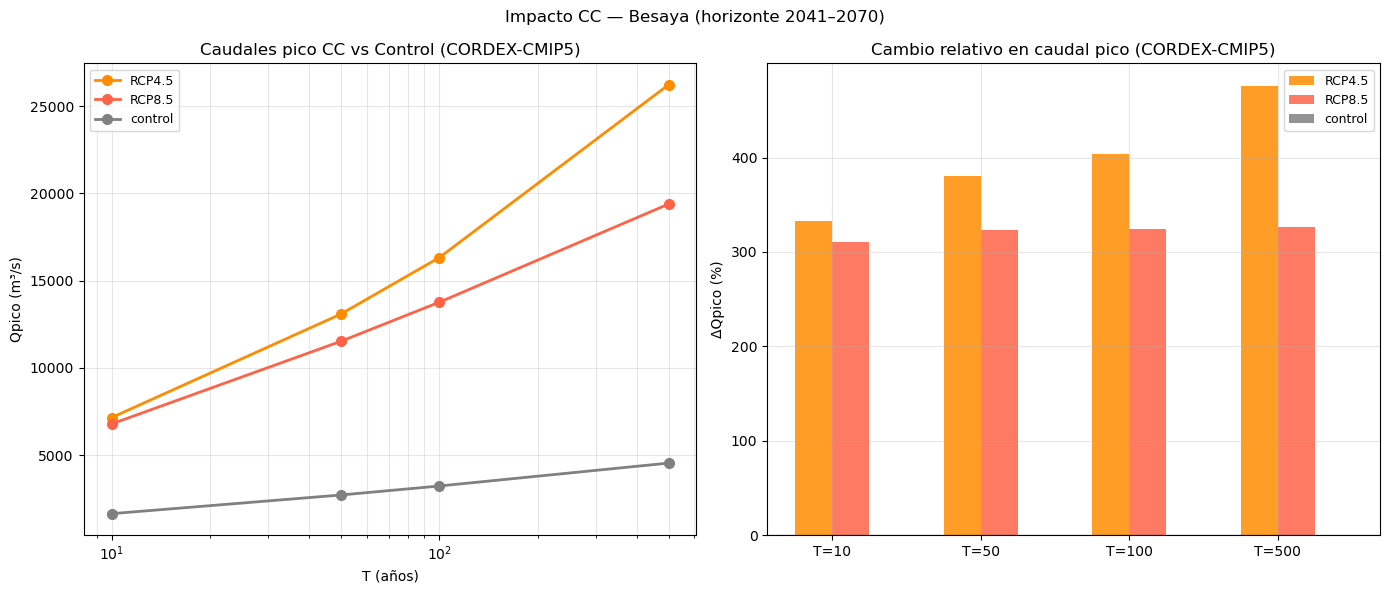

In [17]:
if not impact_df.empty:
    colors_plot = {'Control': 'steelblue', 'RCP4.5': 'darkorange', 'RCP8.5': 'tomato'}
    pivot_Q = impact_df.pivot(index='T_years', columns='scenario', values='Qpico_m3s')
    pivot_d = impact_df.pivot(index='T_years', columns='scenario', values='delta_Q_pct')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    for ssp in pivot_Q.columns:
        c = colors_plot.get(ssp, 'gray')
        ax.semilogx(pivot_Q.index, pivot_Q[ssp], 'o-', color=c, lw=2, ms=7, label=ssp)
    ax.set(xlabel='T (años)', ylabel='Qpico (m³/s)',
           title='Caudales pico CC vs Control (CORDEX-CMIP5)')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

    ax = axes[1]
    x = np.arange(len(T_ref))
    w = 0.25
    for i, ssp in enumerate([s for s in pivot_d.columns if s != 'Control']):
        if ssp in pivot_d.columns:
            ax.bar(x + (i-0.5)*w, pivot_d[ssp].values, w,
                   color=colors_plot.get(ssp, 'gray'), alpha=0.85, label=ssp)
    ax.axhline(0, color='k', lw=0.8)
    ax.set(xticks=x, xticklabels=[f'T={T}' for T in T_ref],
           ylabel='ΔQpico (%)',
           title='Cambio relativo en caudal pico (CORDEX-CMIP5)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Impacto CC — Besaya (horizonte 2041–2070)', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'cc_impact_calibrated.png', dpi=150)
    plt.show()
else:
    print('impact_df vacío — ejecutar celdas anteriores primero')